In [8]:
# Imports and Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from fredapi import Fred
from dotenv import load_dotenv

import yfinance as yf
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

from statsmodels.stats.outliers_influence import variance_inflation_factor

load_dotenv()

pd.set_option("display.max_columns", None)

TICKER = "MSFT"

SIGNAL_THRESHOLD_BPS = 2
BOND_DURATION = 7

In [9]:
# Load FRED API
fred = Fred(api_key=os.getenv("FRED_API_KEY"))

In [10]:
series_map = {
    "bbb_spread": "BAMLC0A4CBBB",
    "hy_spread": "BAMLH0A0HYM2EY",
    "vix": "VIXCLS",
    "us10y": "DGS10",
    "us2y": "DGS2"
}

fred_data = {}

for name, series_id in series_map.items():
    fred_data[name] = fred.get_series(series_id)

macro_df = pd.DataFrame(fred_data)

macro_df = macro_df.sort_index()

macro_df.head()

,bbb_spread,hy_spread,vix,us10y,us2y
1962-01-02,NaN,NaN,NaN,4.06,NaN
1962-01-03,NaN,NaN,NaN,4.03,NaN
1962-01-04,NaN,NaN,NaN,3.99,NaN
1962-01-05,NaN,NaN,NaN,4.02,NaN
1962-01-08,NaN,NaN,NaN,4.03,NaN


In [11]:
# Download Equity Data
ticker = yf.Ticker(TICKER)

equity_df = ticker.history(period="20y")

equity_df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2006-05-08 00:00:00-04:00,16.648529,17.451288,16.411191,16.564762,80693500,0.0,0.0
2006-05-09 00:00:00-04:00,16.578736,16.753249,16.397242,16.487989,75345900,0.0,0.0
2006-05-10 00:00:00-04:00,16.522884,16.606651,16.467040,16.592690,76563300,0.0,0.0
2006-05-11 00:00:00-04:00,16.550808,16.606654,16.159900,16.208763,92916700,0.0,0.0
2006-05-12 00:00:00-04:00,16.152920,16.313473,16.090096,16.173862,83115900,0.0,0.0


In [12]:
# Merge & Clean Data
macro_df.index = (
    pd.to_datetime(macro_df.index)
    .tz_localize(None)
    .normalize()
)

equity_df.index = (
    pd.to_datetime(equity_df.index, utc=True)
    .tz_convert(None)
    .normalize()
)

equity_slim = equity_df[["Close", "Volume"]].copy()

merged = pd.concat(
    [macro_df, equity_slim],
    axis=1,
    join="inner"
)

merged = merged.sort_index()

merged = merged.ffill()

merged.head()

,bbb_spread,hy_spread,vix,us10y,us2y,Close,Volume
2006-05-08,NaN,NaN,12.00,5.12,4.97,16.564762,80693500
2006-05-09,NaN,NaN,11.99,5.13,4.97,16.487989,75345900
2006-05-10,NaN,NaN,11.78,5.13,5.01,16.592690,76563300
2006-05-11,NaN,NaN,12.49,5.14,4.99,16.208763,92916700
2006-05-12,NaN,NaN,14.19,5.19,5.01,16.173862,83115900


In [13]:
# Add Company Financial Ratios
income = ticker.financials

balance = ticker.balance_sheet

ebit = (
    income.loc['EBIT']
    .dropna()
    .iloc[0]
)

interest = (
    income.loc['Interest Expense']
    .dropna()
    .iloc[0]
)

debt = (
    balance.loc['Total Debt']
    .dropna()
    .iloc[0]
)

equity = (
    balance.loc['Stockholders Equity']
    .dropna()
    .iloc[0]
)

interest_coverage = ebit / abs(interest)

debt_to_equity = debt / equity

merged["interest_coverage"] = (
    round(interest_coverage, 2)
)

merged["debt_to_equity"] = (
    round(debt_to_equity, 2)
)

merged.head()

,bbb_spread,hy_spread,vix,us10y,us2y,Close,Volume,interest_coverage,debt_to_equity
2006-05-08,NaN,NaN,12.00,5.12,4.97,16.564762,80693500,52.84,0.18
2006-05-09,NaN,NaN,11.99,5.13,4.97,16.487989,75345900,52.84,0.18
2006-05-10,NaN,NaN,11.78,5.13,5.01,16.592690,76563300,52.84,0.18
2006-05-11,NaN,NaN,12.49,5.14,4.99,16.208763,92916700,52.84,0.18
2006-05-12,NaN,NaN,14.19,5.19,5.01,16.173862,83115900,52.84,0.18


In [14]:
# Feature Engineering
merged["yield_curve_slope"] = (
    merged["us10y"] - merged["us2y"]
)

for lag in [1, 5, 21]:

    merged[f"spread_lag_{lag}d"] = (
        merged["bbb_spread"].shift(lag)
    )

merged["spread_chg_21d"] = (
    merged["bbb_spread"].diff(21)
)

merged["hy_spread_lag_1d"] = (
    merged["hy_spread"].shift(1)
)

merged["vix_lag_1d"] = (
    merged["vix"].shift(1)
)

equity_returns = (
    merged["Close"].pct_change()
)

for window in [21, 63]:

    merged[f"equity_vol_{window}d"] = (
        equity_returns
        .rolling(window)
        .std()
        * np.sqrt(252)
    )

merged["equity_mom_1m"] = (
    merged["Close"].pct_change(21)
)

merged["equity_mom_3m"] = (
    merged["Close"].pct_change(63)
)

merged = merged.ffill()

merged = merged.dropna()

merged.head()

,bbb_spread,hy_spread,vix,us10y,us2y,Close,Volume,interest_coverage,debt_to_equity,yield_curve_slope,spread_lag_1d,spread_lag_5d,spread_lag_21d,spread_chg_21d,hy_spread_lag_1d,vix_lag_1d,equity_vol_21d,equity_vol_63d,equity_mom_1m,equity_mom_3m
2023-06-07,1.73,8.44,13.94,3.79,4.56,316.589447,40717100,52.84,0.18,-0.77,1.73,1.76,1.83,-0.10,8.43,13.96,0.233566,0.276188,0.050014,0.277441
2023-06-08,1.74,8.42,13.65,3.73,4.52,318.430023,23277700,52.84,0.18,-0.79,1.73,1.76,1.83,-0.09,8.44,13.94,0.232080,0.275534,0.061795,0.291895
2023-06-09,1.73,8.39,13.83,3.75,4.59,319.927917,22529000,52.84,0.18,-0.84,1.74,1.73,1.83,-0.10,8.42,13.65,0.226307,0.272815,0.048652,0.317448
2023-06-12,1.74,8.42,15.01,3.73,4.55,324.881622,24260300,52.84,0.18,-0.82,1.73,1.73,1.83,-0.09,8.39,13.83,0.227959,0.271571,0.072444,0.309765
2023-06-13,1.71,8.36,14.61,3.84,4.67,327.270355,22951300,52.84,0.18,-0.83,1.74,1.73,1.82,-0.11,8.42,15.01,0.226824,0.267732,0.084315,0.284638


In [15]:
# VIF Analysis
vif_df = merged.copy()

vif_X = vif_df.drop(
    columns=["bbb_spread", "hy_spread"]
)

vif_X = vif_X.select_dtypes(
    include=[np.number]
)

vif_X = vif_X.replace(
    [np.inf, -np.inf],
    np.nan
)

vif_X = vif_X.dropna()

vif_results = pd.DataFrame()

vif_results["feature"] = vif_X.columns

vif_results["VIF"] = [

    variance_inflation_factor(
        vif_X.values,
        i
    )

    for i in range(vif_X.shape[1])
]

vif_results = vif_results.sort_values(
    by="VIF",
    ascending=False
)

vif_results.head(20)

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
2,us2y,inf
7,yield_curve_slope,inf
1,us10y,4.503600e+14
10,spread_lag_21d,2.739508e+02
8,spread_lag_1d,2.603731e+02
11,spread_chg_21d,4.903750e+01
12,hy_spread_lag_1d,4.125507e+01
9,spread_lag_5d,3.859431e+01
3,Close,1.084646e+01
13,vix_lag_1d,8.426877e+00


In [16]:
# Drop High-VIF Features
features_to_drop = [
    "us2y",
    "spread_lag_5d",
    "spread_lag_21d"
]

merged = merged.drop(
    columns=features_to_drop,
    errors="ignore"
)

print("Dropped Features:")

for feature in features_to_drop:
    print("-", feature)

merged.head()

Dropped Features:
- us2y
- spread_lag_5d
- spread_lag_21d


,bbb_spread,hy_spread,vix,us10y,Close,Volume,interest_coverage,debt_to_equity,yield_curve_slope,spread_lag_1d,spread_chg_21d,hy_spread_lag_1d,vix_lag_1d,equity_vol_21d,equity_vol_63d,equity_mom_1m,equity_mom_3m
2023-06-07,1.73,8.44,13.94,3.79,316.589447,40717100,52.84,0.18,-0.77,1.73,-0.10,8.43,13.96,0.233566,0.276188,0.050014,0.277441
2023-06-08,1.74,8.42,13.65,3.73,318.430023,23277700,52.84,0.18,-0.79,1.73,-0.09,8.44,13.94,0.232080,0.275534,0.061795,0.291895
2023-06-09,1.73,8.39,13.83,3.75,319.927917,22529000,52.84,0.18,-0.84,1.74,-0.10,8.42,13.65,0.226307,0.272815,0.048652,0.317448
2023-06-12,1.74,8.42,15.01,3.73,324.881622,24260300,52.84,0.18,-0.82,1.73,-0.09,8.39,13.83,0.227959,0.271571,0.072444,0.309765
2023-06-13,1.71,8.36,14.61,3.84,327.270355,22951300,52.84,0.18,-0.83,1.74,-0.11,8.42,15.01,0.226824,0.267732,0.084315,0.284638


In [17]:
# Create ML Dataset
two_years_ago = (
    merged.index.max()
    - pd.Timedelta(days=730)
)

df = merged[
    merged.index > two_years_ago
].copy()

X = df.drop(
    columns=["bbb_spread", "hy_spread"]
)

y = df["bbb_spread"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

print("Train Size:", len(X_train))
print("Test Size:", len(X_test))

Train Size: 400
Test Size: 101


In [18]:
# Train Random Forest Model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

r2 = r2_score(
    y_test,
    predictions
)

mae = mean_absolute_error(
    y_test,
    predictions
)

print(f"R² Score: {r2:.4f}")

print(f"MAE: {mae:.4f}%")

R² Score: 0.8661
MAE: 0.0162%


In [19]:
# Generate Mispricing Signals
signals = pd.DataFrame({
    "actual_spread": y_test,
    "fair_spread": predictions
}, index=y_test.index)

signals["mispricing_bps"] = (
    (
        signals["actual_spread"]
        - signals["fair_spread"]
    ) * 100
)

conditions = [
    signals["mispricing_bps"] > SIGNAL_THRESHOLD_BPS,
    signals["mispricing_bps"] < -SIGNAL_THRESHOLD_BPS
]

choices = ["BUY", "SELL"]

signals["signal"] = np.select(
    conditions,
    choices,
    default="FLAT"
)

signals.head()

,actual_spread,fair_spread,mispricing_bps,signal
2025-12-09,1.00,1.0040,-0.40,FLAT
2025-12-10,1.00,0.9975,0.25,FLAT
2025-12-11,1.00,0.9939,0.61,FLAT
2025-12-12,1.01,0.9970,1.30,FLAT
2025-12-15,1.02,1.0106,0.94,FLAT


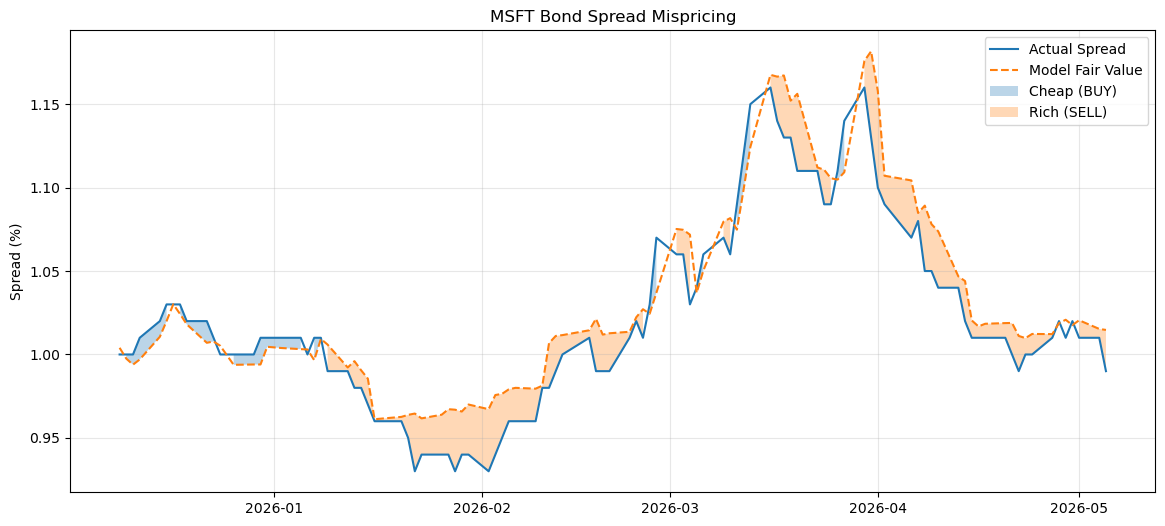

In [20]:
# Visualize Mispricing
plt.figure(figsize=(14,6))

plt.plot(
    signals.index,
    signals["actual_spread"],
    label="Actual Spread"
)

plt.plot(
    signals.index,
    signals["fair_spread"],
    linestyle="--",
    label="Model Fair Value"
)

plt.fill_between(
    signals.index,
    signals["actual_spread"],
    signals["fair_spread"],
    where=(
        signals["actual_spread"]
        > signals["fair_spread"]
    ),
    alpha=0.3,
    label="Cheap (BUY)"
)

plt.fill_between(
    signals.index,
    signals["actual_spread"],
    signals["fair_spread"],
    where=(
        signals["actual_spread"]
        < signals["fair_spread"]
    ),
    alpha=0.3,
    label="Rich (SELL)"
)

plt.title(
    f"{TICKER} Bond Spread Mispricing"
)

plt.ylabel("Spread (%)")

plt.grid(True, alpha=0.3)

plt.legend()

plt.show()

In [21]:
# Backtest Strategy
signals["delta_spread"] = (
    signals["actual_spread"].diff()
)

signals["bond_return"] = (
    -BOND_DURATION
    * (signals["delta_spread"] / 100)
)

position_map = {
    "BUY": 1,
    "SELL": -1,
    "FLAT": 0
}

signals["position"] = (
    signals["signal"].map(position_map)
)

signals["position"] = (
    signals["position"].shift(1)
)

signals = signals.dropna()

signals["strategy_return"] = (
    signals["position"]
    * signals["bond_return"]
)

signals["benchmark_return"] = (
    signals["bond_return"]
)

signals["strategy_cumulative"] = (
    1 + signals["strategy_return"]
).cumprod()

signals["benchmark_cumulative"] = (
    1 + signals["benchmark_return"]
).cumprod()

signals.head()

,actual_spread,fair_spread,mispricing_bps,signal,delta_spread,bond_return,position,strategy_return,benchmark_return,strategy_cumulative,benchmark_cumulative
2025-12-10,1.00,0.9975,0.25,FLAT,0.00,-0.0000,0.0,-0.0,-0.0000,1.0,1.000000
2025-12-11,1.00,0.9939,0.61,FLAT,0.00,-0.0000,0.0,-0.0,-0.0000,1.0,1.000000
2025-12-12,1.01,0.9970,1.30,FLAT,0.01,-0.0007,0.0,-0.0,-0.0007,1.0,0.999300
2025-12-15,1.02,1.0106,0.94,FLAT,0.01,-0.0007,0.0,-0.0,-0.0007,1.0,0.998600
2025-12-16,1.03,1.0200,1.00,FLAT,0.01,-0.0007,0.0,-0.0,-0.0007,1.0,0.997901


In [22]:
# Performance Metrics
strategy_returns = (
    signals["strategy_return"]
)

sharpe = (
    strategy_returns.mean()
    / strategy_returns.std()
) * np.sqrt(252)

roll_max = (
    signals["strategy_cumulative"]
    .cummax()
)

drawdown = (
    signals["strategy_cumulative"]
    - roll_max
) / roll_max

max_drawdown = drawdown.min()

total_return = (
    signals["strategy_cumulative"]
    .iloc[-1] - 1
)

print(f"Total Return: {total_return:.2%}")

print(f"Sharpe Ratio: {sharpe:.2f}")

print(f"Max Drawdown: {max_drawdown:.2%}")

Total Return: -0.07%
Sharpe Ratio: -0.21
Max Drawdown: -0.98%


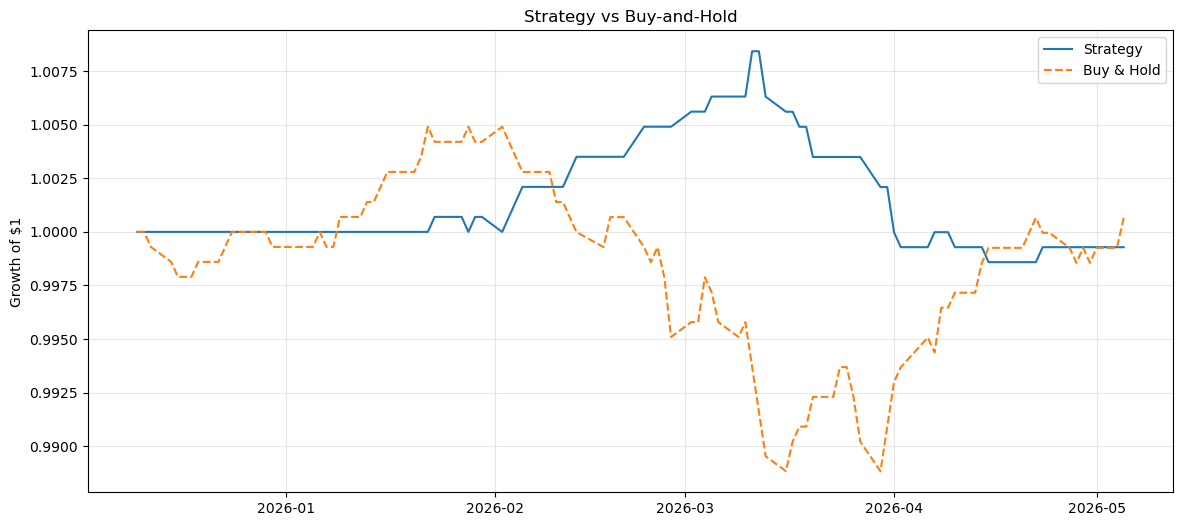

In [23]:
# Plot Strategy Returns
plt.figure(figsize=(14,6))

plt.plot(
    signals.index,
    signals["strategy_cumulative"],
    label="Strategy"
)

plt.plot(
    signals.index,
    signals["benchmark_cumulative"],
    linestyle="--",
    label="Buy & Hold"
)

plt.title("Strategy vs Buy-and-Hold")

plt.ylabel("Growth of $1")

plt.grid(True, alpha=0.3)

plt.legend()

plt.show()

In [24]:
# Feature Importance
feature_importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance.head(10)

spread_lag_1d       0.946339
vix                 0.019342
spread_chg_21d      0.012003
hy_spread_lag_1d    0.007453
Volume              0.002454
Close               0.002250
vix_lag_1d          0.002037
us10y               0.001698
equity_vol_63d      0.001610
equity_mom_1m       0.001411
dtype: float64

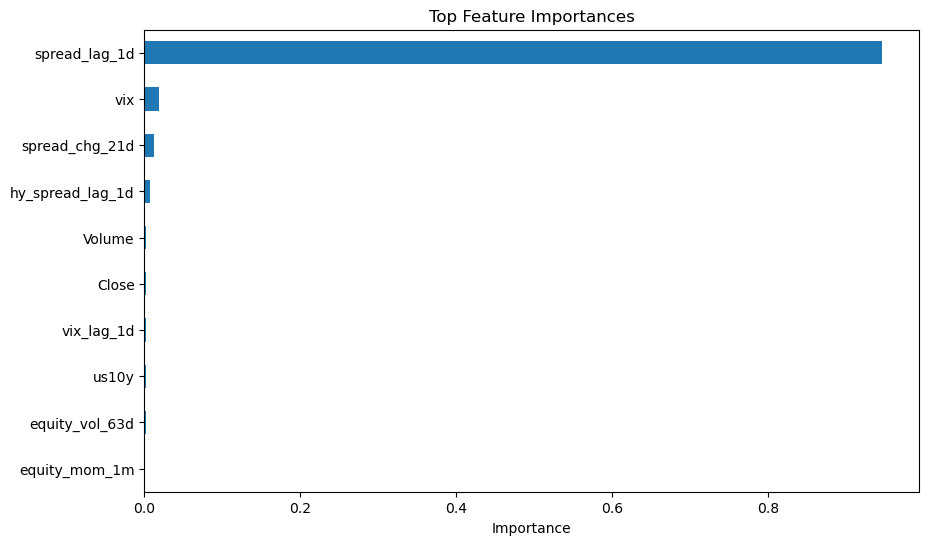

In [25]:
# Plot Feature Importance
feature_importance.head(10).plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top Feature Importances")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()